In [26]:
# Library yang digunakan
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## 💡 Load Data

In [27]:
#Load Dataser

version_5_5 = f"../data/review_genshin_5.5_clear.csv"
version_5_4 = f"../data/review_genshin_5.4_clear.csv"
review_5_5 = pd.read_csv(version_5_5)
review_5_4 = pd.read_csv(version_5_4)

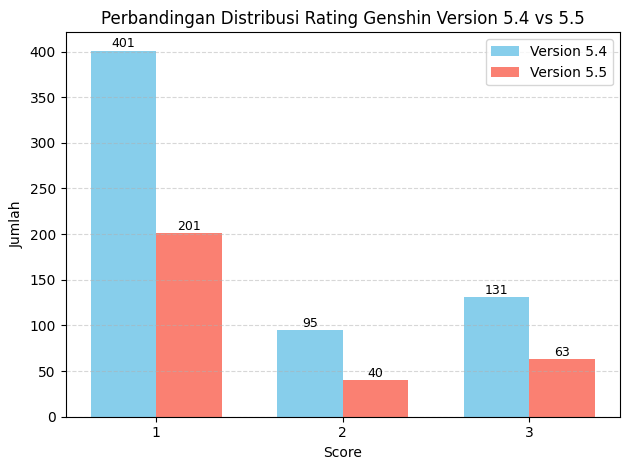

In [28]:
# Hitung jumlah score masing-masing versi
score_5_5 = review_5_5['Score'].value_counts().sort_index()
score_5_4 = review_5_4['Score'].value_counts().sort_index()

# Pastikan semua rating dari 1 sampai 5 ada di kedua data
all_scores = sorted(set(score_5_5.index).union(score_5_4.index))

score_5_5 = score_5_5.reindex(all_scores, fill_value=0)
score_5_4 = score_5_4.reindex(all_scores, fill_value=0)

# Konversi ke array
x = np.arange(len(all_scores))  # posisi x untuk setiap score
width = 0.35  # lebar tiap bar

# Plot barplot berdampingan
fig, ax = plt.subplots()
bar1 = ax.bar(x - width/2, score_5_4.values, width, label='Version 5.4', color='skyblue')
bar2 = ax.bar(x + width/2, score_5_5.values, width, label='Version 5.5', color='salmon')

# Tambahkan label jumlah di atas setiap bar
for bar in bar1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(height), 
            ha='center', va='bottom', fontsize=9)

for bar in bar2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5, str(height), 
            ha='center', va='bottom', fontsize=9)

# Label dan tampilan
ax.set_xlabel('Score')
ax.set_ylabel('Jumlah')
ax.set_title('Perbandingan Distribusi Rating Genshin Version 5.4 vs 5.5')
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in all_scores])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

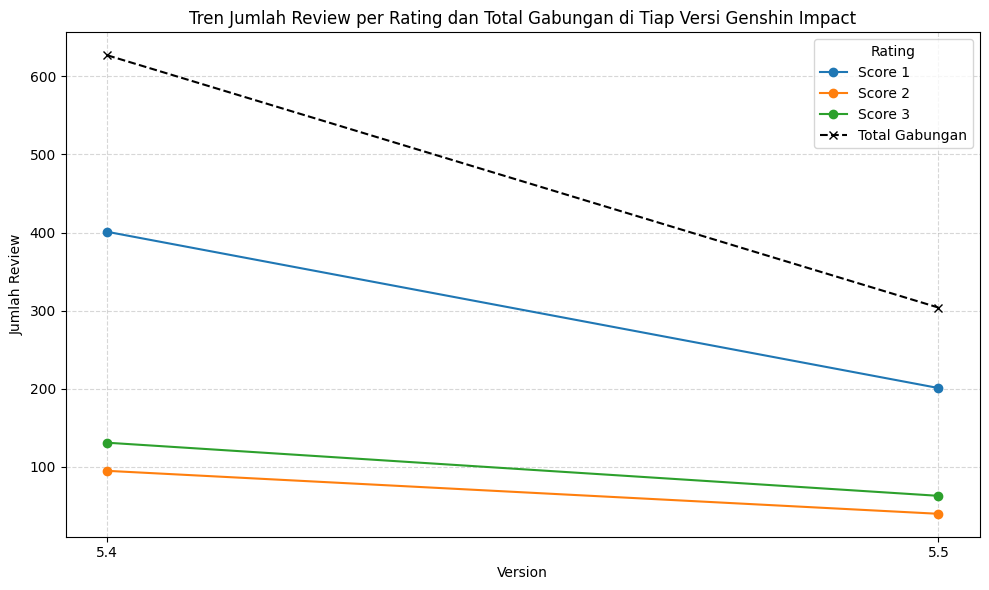

In [29]:
# Daftar file dan versi
version_files = {
    '5.4': '../data/review_genshin_5.4_clear.csv',
    '5.5': '../data/review_genshin_5.5_clear.csv',
}

# Inisialisasi DataFrame kosong
all_data = pd.DataFrame()
total_data = pd.DataFrame()

# Loop semua versi
for version, file in version_files.items():
    df = pd.read_csv(file)
    score_count = df['Score'].value_counts().sort_index()
    score_count.name = version  # ganti nama series menjadi versi
    all_data = pd.concat([all_data, score_count], axis=1)
    
    # Total review gabungan per version (jumlah semua rating)
    total_review = df['Score'].count()
    total_data[version] = [total_review] * len(score_count)

# Pastikan index-nya (score) urut
all_data = all_data.fillna(0).astype(int).sort_index()
total_data = total_data.fillna(0)

# Transpose agar versi jadi index, lalu plot per score dan total gabungan
plt.figure(figsize=(10, 6))

# Plot per rating (Score 1, Score 2, dst.)
for score in all_data.index:
    plt.plot(all_data.columns, all_data.loc[score], marker='o', label=f'Score {score}')

# Plot total gabungan per versi
plt.plot(total_data.columns, total_data.iloc[0], marker='x', linestyle='--', label='Total Gabungan', color='black')

# Label dan tampilan
plt.title('Tren Jumlah Review per Rating dan Total Gabungan di Tiap Versi Genshin Impact')
plt.xlabel('Version')
plt.ylabel('Jumlah Review')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Rating')
plt.tight_layout()
plt.show()